<a href="https://colab.research.google.com/github/huonggnguyen-source/AIHC-5020/blob/main/Nguyen_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print(os.path.exists('/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb'))

True


In [3]:
!pip install -q wfdb


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.8 MB/s eta 0:00:00


In [4]:
# Problem 1: Loading and Processing MIT-BIH Data

In [5]:
import os
import wfdb
import pandas as pd


def load_ecg_data(record_number, max_duration, wfdb_root):
    """Loads an ECG recording and its annotations from WFDB files and truncates

    both to max_duration seconds.

    Parameters:
    record_number (int or str): Identifier for the ECG record (e.g., 100).
    max_duration (int): Maximum duration of the signal to load in seconds.
    wfdb_root (str): Root directory path containing the MIT-BIH dataset.

    Returns:
    tuple: (ecg_df, annotations_df, sample_rate)
    """

    record_path = os.path.join(wfdb_root, str(record_number))


    ecg_record = wfdb.rdrecord(record_path)
    ecg_ann = wfdb.rdann(record_path, extension="atr")


    sample_rate = ecg_record.fs
    cutoff_sample_index = int(max_duration * sample_rate)


    ecg_signal_truncated = ecg_record.p_signal[:cutoff_sample_index]
    ecg_df = pd.DataFrame(
        data=ecg_signal_truncated, columns=ecg_record.sig_name
    )


    raw_ann_df = pd.DataFrame(
        {"annotation_index": ecg_ann.sample, "annotation_text": ecg_ann.symbol}
    )


    annotations_df = (
        raw_ann_df[raw_ann_df["annotation_index"] < cutoff_sample_index]
        .reset_index(drop=True)
    )


    return ecg_df, annotations_df, sample_rate

wfdb_directory = "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"
rec_num = 100
max_sec = 30

ecg_df, annotations_df, fs = load_ecg_data(
    record_number=rec_num, max_duration=max_sec, wfdb_root=wfdb_directory
)

print(f"Sample Rate: {fs} Hz")
print(f"ECG DataFrame Shape: {ecg_df.shape}")
print(f"Annotations Count: {len(annotations_df)}\n")

print("--- ECG DataFrame Preview ---")
print(ecg_df.head())

print("\n--- Annotations DataFrame Preview ---")
print(annotations_df.head())

Sample Rate: 360 Hz
ECG DataFrame Shape: (10800, 2)
Annotations Count: 38

--- ECG DataFrame Preview ---
    MLII     V5
0 -0.145 -0.065
1 -0.145 -0.065
2 -0.145 -0.065
3 -0.145 -0.065
4 -0.145 -0.065

--- Annotations DataFrame Preview ---
   annotation_index annotation_text
0                18               +
1                77               N
2               370               N
3               662               N
4               946               N


In [6]:
ecg_df, annotations_df, sample_rate = load_ecg_data(
    record_number=100,
    max_duration=10,
    wfdb_root=wfdb_directory
)

print(f"Sample Rate: {sample_rate} Hz")
print(f"Total ECG samples loaded (should be 3600): {len(ecg_df)}\n")

print("--- Last 5 rows of ecg_df ---")
print(ecg_df.tail(5))

print("\n--- Last 5 rows of annotations_df ---")
print(annotations_df.tail(5))

Sample Rate: 360 Hz
Total ECG samples loaded (should be 3600): 3600

--- Last 5 rows of ecg_df ---
       MLII     V5
3595 -0.385 -0.285
3596 -0.395 -0.285
3597 -0.390 -0.295
3598 -0.400 -0.290
3599 -0.405 -0.285

--- Last 5 rows of annotations_df ---
    annotation_index annotation_text
9               2402               N
10              2706               N
11              2998               N
12              3282               N
13              3560               N


In [7]:
ecg_df, annotations_df, sample_rate = load_ecg_data(
    record_number=101,
    max_duration=15,
    wfdb_root=wfdb_directory
)

print(f"Sample Rate: {sample_rate} Hz")
print(f"Total ECG samples loaded (should be 3600): {len(ecg_df)}\n")

print("--- Last 5 rows of ecg_df ---")
print(ecg_df.tail(5))

print("\n--- Last 5 rows of annotations_df ---")
print(annotations_df.tail(5))

Sample Rate: 360 Hz
Total ECG samples loaded (should be 3600): 5400

--- Last 5 rows of ecg_df ---
       MLII     V1
5395 -0.275 -0.035
5396 -0.250 -0.015
5397 -0.245 -0.005
5398 -0.245  0.005
5399 -0.250  0.000

--- Last 5 rows of annotations_df ---
    annotation_index annotation_text
13              3960               N
14              4283               N
15              4609               N
16              4928               N
17              5241               N


In [8]:
ecg_df, annotations_df, fs = load_ecg_data(
    record_number=101,
    max_duration=15,
     wfdb_root=wfdb_directory
)

print("--- Last 5 rows of ecg_df ---")
display(ecg_df.tail(5))

print("\n--- Last 5 rows of annotations_df ---")
display(annotations_df.tail(5))

--- Last 5 rows of ecg_df ---


,MLII,V1
5395,-0.275,-0.035
5396,-0.250,-0.015
5397,-0.245,-0.005
5398,-0.245,0.005
5399,-0.250,0.000



--- Last 5 rows of annotations_df ---


,annotation_index,annotation_text
13,3960,N
14,4283,N
15,4609,N
16,4928,N
17,5241,N


In [1]:
#Problem 2: Visualizing ECG Segments and Annotations

In [6]:
!pip install -q wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.7 MB/s eta 0:00:00


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os
print(os.path.exists('/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb'))

True


In [17]:
%matplotlib inline

In [12]:
import os
import wfdb
import pandas as pd

def load_ecg_data(record_number, max_duration, wfdb_root):
    """
    Loads an ECG recording and its annotations from WFDB files and truncates
    both to max_duration seconds.
    """
    # 1. Assemble record path (without file extensions)
    record_path = os.path.join(wfdb_root, str(record_number))

    # 2. Load waveform record and annotations metadata
    ecg_record = wfdb.rdrecord(record_path)
    ecg_ann = wfdb.rdann(record_path, extension='atr')

    # 3. Extract sampling frequency (fs) and compute cutoff sample index
    sample_rate = ecg_record.fs
    cutoff_sample_index = int(max_duration * sample_rate)

    # 4. Construct truncated ecg_df
    ecg_signal_truncated = ecg_record.p_signal[:cutoff_sample_index]
    ecg_df = pd.DataFrame(data=ecg_signal_truncated, columns=ecg_record.sig_name)

    # 5. Construct truncated annotations_df
    raw_ann_df = pd.DataFrame({
        'annotation_index': ecg_ann.sample,
        'annotation_text': ecg_ann.symbol
    })

    annotations_df = raw_ann_df[raw_ann_df['annotation_index'] < cutoff_sample_index].reset_index(drop=True)

    # 6. Return values in required order
    return ecg_df, annotations_df, sample_rate

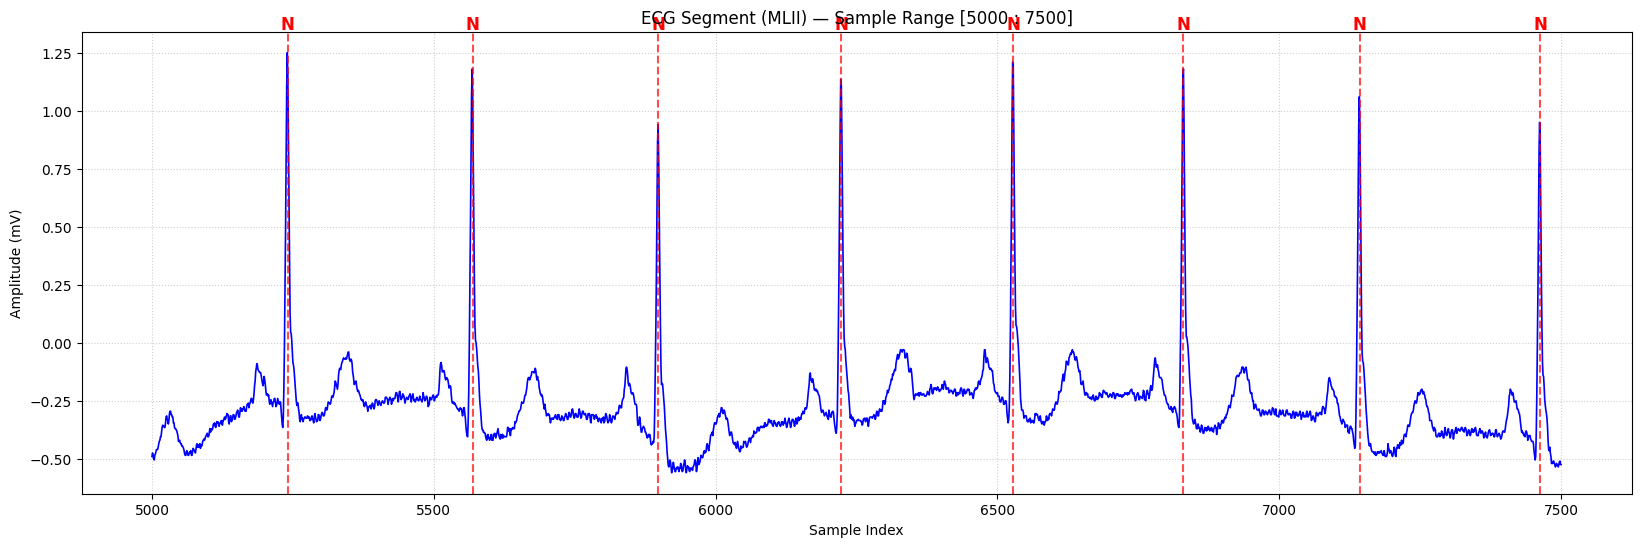

In [18]:
# 1. Load data for record 101
ecg_df_101, ann_df_101, fs_101 = load_ecg_data(
    record_number=101,
    max_duration=30,
    wfdb_root='/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb'
)

# 2. Call the plotting function directly
plot_ecg_segment(
    ecg_df=ecg_df_101,
    annotations_df=ann_df_101,
    channel_name='MLII',
    start_index=5000,
    end_index=7500
)

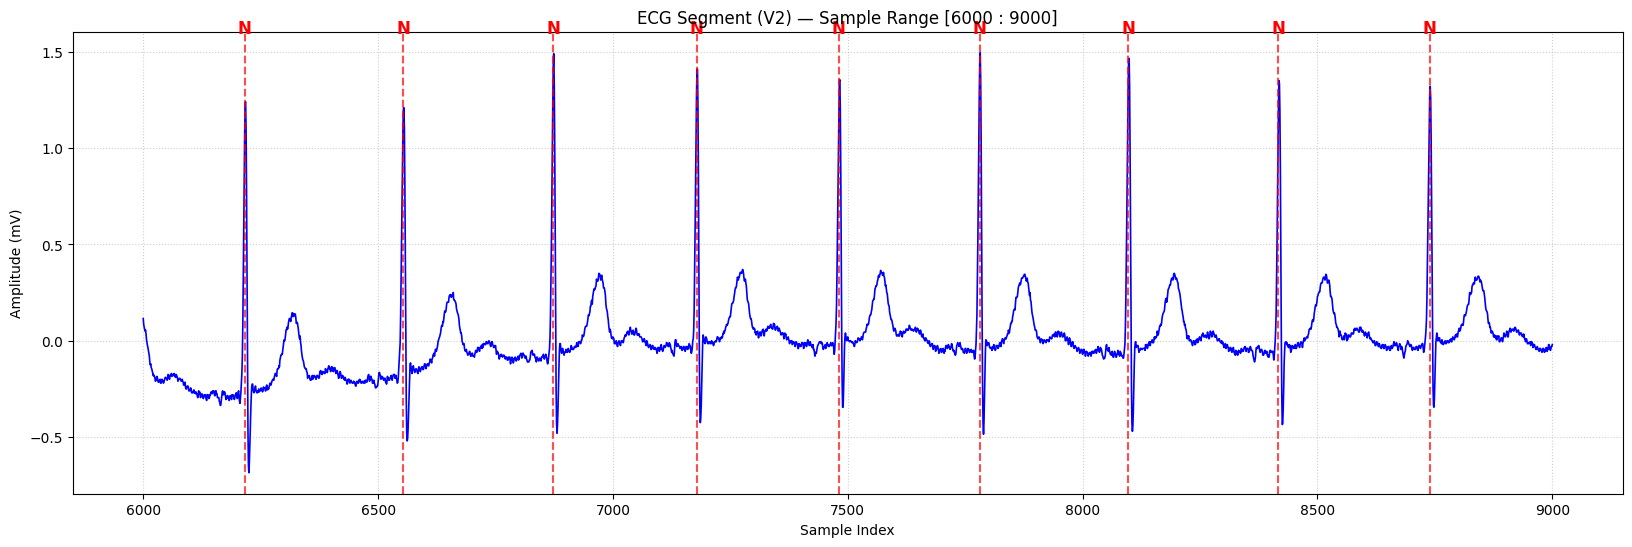

In [20]:
# 1. Load record 103 data for 30 seconds
ecg_df_103, ann_df_103, fs_103 = load_ecg_data(
    record_number=103,
    max_duration=30,
    wfdb_root='/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb'
)

# 2. Plot channel V2 for indices 6000 to 9000
plot_ecg_segment(
    ecg_df=ecg_df_103,
    annotations_df=ann_df_103,
    channel_name='V2',
    start_index=6000,
    end_index=9000
)

In [21]:
#Problem 3: Segment Table Transformation

In [22]:
import math
import numpy as np
import pandas as pd


def create_segment_table(
    record_number, max_duration, wfdb_root, segment_duration
):
    """Transforms a long-format ECG recording into a structured segment table DataFrame.

    Each row represents one segment of a specific channel.
    """
    # 1. Load long format ECG DataFrame, annotations, and sample rate using Problem 1 function
    ecg_df, _, sample_rate = load_ecg_data(record_number, max_duration, wfdb_root)

    # 2. Determine total number of segments needed using ceil
    num_segments = math.ceil(max_duration / segment_duration)

    # 3. Split the ECG DataFrame data and index into segments
    # np.array_split handles unequal split sizes automatically
    data_segments = np.array_split(ecg_df.values, num_segments)
    index_segments = np.array_split(ecg_df.index.values, num_segments)

    channel_names = ecg_df.columns.tolist()
    row_dicts = []

    # 4. Iterate through each segment and channel to construct row dictionaries
    for seg_idx in range(num_segments):
        seg_data = data_segments[seg_idx]  # Array of shape [n_samples, n_channels]
        seg_indices = index_segments[seg_idx]

        # Extract segment metadata
        n_samples = len(seg_data)
        segment_start_index = seg_indices[0]

        # Iterate through channels
        for ch_idx, channel_name in enumerate(channel_names):
            # Extract signal array for current channel
            channel_signal = seg_data[:, ch_idx]

            row_dict = {
                "record_number": record_number,
                "segment_index": seg_idx,
                "sample_rate": sample_rate,
                "n_samples": n_samples,
                "channel_name": channel_name,
                "segment_start_index": segment_start_index,
                "segment": channel_signal,
            }
            row_dicts.append(row_dict)

    segment_table_df = pd.DataFrame(row_dicts)
    return segment_table_df


In [23]:
# 1. Generate segment table for record 100 with 4-second segments
segment_table_df = create_segment_table(
    record_number=100,
    max_duration=30,
    wfdb_root='/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb',
    segment_duration=4
)

# 2. Display total table shape and first 5 rows
print(f"Segment Table Shape: {segment_table_df.shape}")
display(segment_table_df.head(5))

Segment Table Shape: (16, 7)


,record_number,segment_index,sample_rate,n_samples,channel_name,segment_start_index,segment
0,100,0,360,1350,MLII,0,"[-0.145, -0.145, -0.145, -0.145, -0.145, -0.14..."
1,100,0,360,1350,V5,0,"[-0.065, -0.065, -0.065, -0.065, -0.065, -0.06..."
2,100,1,360,1350,MLII,1350,"[-0.31, -0.305, -0.31, -0.315, -0.32, -0.315, ..."
3,100,1,360,1350,V5,1350,"[-0.23, -0.235, -0.245, -0.255, -0.255, -0.225..."
4,100,2,360,1350,MLII,2700,"[-0.255, -0.105, 0.105, 0.355, 0.6, 0.81, 0.89..."


In [24]:
# 1. Generate segment table for record 102 with 4-second segments
segment_table_df = create_segment_table(
    record_number=102,
    max_duration=30,
    wfdb_root='/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb',
    segment_duration=4
)

# 2. Display total table shape and first 5 rows
print(f"Segment Table Shape: {segment_table_df.shape}")
display(segment_table_df.head(5))

Segment Table Shape: (16, 7)


,record_number,segment_index,sample_rate,n_samples,channel_name,segment_start_index,segment
0,102,0,360,1350,V5,0,"[-0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0...."
1,102,0,360,1350,V2,0,"[0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.0..."
2,102,1,360,1350,V5,1350,"[-0.41, -0.4, -0.385, -0.37, -0.34, -0.305, -0..."
3,102,1,360,1350,V2,1350,"[-2.465, -2.285, -2.11, -1.905, -1.67, -1.425,..."
4,102,2,360,1350,V5,2700,"[-0.225, -0.23, -0.24, -0.245, -0.255, -0.25, ..."


In [25]:
# Problem 4: Creating a DICOM Series Manifest

In [26]:
!pip install -q pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.7 MB/s eta 0:00:00


In [27]:
import os
print(os.path.exists('/content/drive/MyDrive/AIHC5020/dicom/tcia/LIDC-IDRI'))

True


In [37]:
from pathlib import Path
import pandas as pd
import pydicom


def create_dicom_manifest(root_dir: str) -> pd.DataFrame:
    """Scans a directory of DICOM files and builds a manifest DataFrame summarizing

    each unique imaging series.
    """
    root_path = Path(root_dir)
    manifest_rows = []

    # Find all unique series directories containing .dcm files
    dcm_files = list(root_path.rglob("*.dcm"))
    series_dirs = set(dcm_file.parent for dcm_file in dcm_files)

    for series_dir in series_dirs:
        series_dcm_files = list(series_dir.glob("*.dcm"))
        n_images = len(series_dcm_files)

        if n_images == 0:
            continue

        sample_file = series_dcm_files[0]

        try:
            ds = pydicom.dcmread(sample_file, stop_before_pixels=True)

            row_data = {
                "patient_id": str(ds.get("PatientID", "N/A")),
                "study_date": str(ds.get("StudyDate", "N/A")),
                "modality": str(ds.get("Modality", "N/A")),
                "study_description": str(ds.get("StudyDescription", "N/A")),
                "series_description": str(
                    ds.get("SeriesDescription", "N/A")
                ),
                "n_images": n_images,
                "study_instance_uid": str(ds.get("StudyInstanceUID", "N/A")),
                "series_instance_uid": str(ds.get("SeriesInstanceUID", "N/A")),
                "series_path": str(series_dir),
            }
            manifest_rows.append(row_data)

        except Exception as e:
            print(f"Warning: Could not read DICOM header for {sample_file}: {e}")

    manifest_df = pd.DataFrame(manifest_rows)

    if not manifest_df.empty:
        # Sort patient_id ascending, then series_description descending
        manifest_df = manifest_df.sort_values(
            by=["patient_id", "series_description"], ascending=[True, False]
        ).reset_index(drop=True)

    return manifest_df


# --- Run Test ---
dicom_root = "/content/drive/MyDrive/AIHC5020/dicom/tcia/LIDC-IDRI"
manifest_df = create_dicom_manifest(dicom_root)

# Check top 5 rows
display(manifest_df.head(5))

,patient_id,study_date,modality,study_description,series_description,n_images,study_instance_uid,series_instance_uid,series_path
0,LIDC-IDRI-0001,20000101,SEG,N/A,Segmentation of Nodule 1 - Annotation Nodule 001,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89314.1553284067.990548,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
1,LIDC-IDRI-0001,20000101,SEG,N/A,Segmentation of Nodule 1 - Annotation MI014_12127,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89355.1553284075.626419,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
2,LIDC-IDRI-0001,20000101,SEG,N/A,Segmentation of Nodule 1 - Annotation IL057_12...,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89316.1553284071.471973,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
3,LIDC-IDRI-0001,20000101,SEG,N/A,Segmentation of Nodule 1 - Annotation 0,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89358.1553284079.860324,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
4,LIDC-IDRI-0001,20000101,SR,N/A,Nodule 1 - Annotation Nodule 001 evaluations,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89315.1553284069.532969,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...


In [42]:

patient_0002_top5 = manifest_df[manifest_df['patient_id'] == 'LIDC-IDRI-0002'].head(5).reset_index(drop=True)
display(patient_0002_top5)

,patient_id,study_date,modality,study_description,series_description,n_images,study_instance_uid,series_instance_uid,series_path
0,LIDC-IDRI-0002,20000101,SR,N/A,Nodule 1 - Annotation MI014_11691 evaluations,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.2.276.0.7230010.3.1.3.0.89454.1553284121.39902,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
1,LIDC-IDRI-0002,20000101,SR,N/A,Nodule 1 - Annotation 8 evaluations,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.2.276.0.7230010.3.1.3.0.89456.1553284129.203669,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
2,LIDC-IDRI-0002,20000101,SEG,N/A,Segmentation of Nodule 1 - Annotation 8,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.2.276.0.7230010.3.1.3.0.89455.1553284125.863850,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
3,LIDC-IDRI-0002,20000101,SEG,N/A,Segmentation of Nodule 1 - Annotation MI014_11691,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.2.276.0.7230010.3.1.3.0.89453.1553284117.905274,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
4,LIDC-IDRI-0002,20000101,CT,N/A,N/A,261,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...


In [43]:
#Challenge Case: Show the rows of the Manifest where the modality is CT

In [44]:
ct_manifest_df = manifest_df[manifest_df["modality"] == "CT"].reset_index(
    drop=True
)

print(f"Total CT Series Found: {len(ct_manifest_df)}")
display(ct_manifest_df)

Total CT Series Found: 6


,patient_id,study_date,modality,study_description,series_description,n_images,study_instance_uid,series_instance_uid,series_path
0,LIDC-IDRI-0001,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
1,LIDC-IDRI-0002,20000101,CT,N/A,N/A,261,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
2,LIDC-IDRI-0003,20000101,CT,N/A,N/A,140,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
3,LIDC-IDRI-0004,20000101,CT,N/A,N/A,241,1.3.6.1.4.1.14519.5.2.1.6279.6001.191425307197...,1.3.6.1.4.1.14519.5.2.1.6279.6001.323541312620...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
4,LIDC-IDRI-0005,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
5,LIDC-IDRI-0006,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...,1.3.6.1.4.1.14519.5.2.1.6279.6001.132817748896...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...


In [45]:
#Problem 5: Visualizing DICOM slices

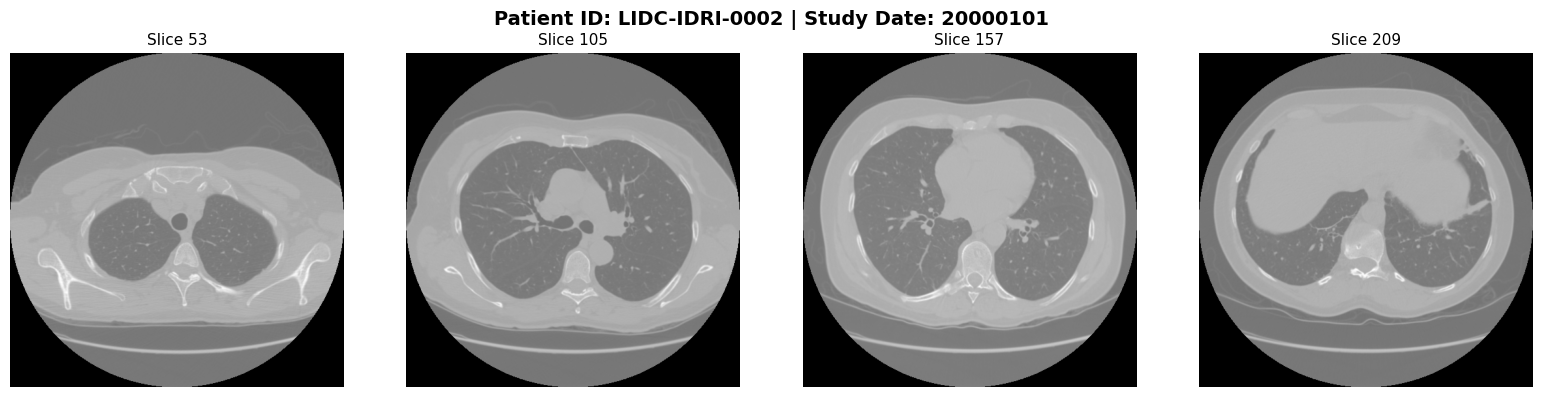

In [47]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom


def visualize_ct_series(manifest_row: pd.Series):
    """Loads a CT DICOM series, validates modality and image count, picks 4 evenly

    spaced slices based on InstanceNumber, and plots them in a 1x4 montage.
    """
    # 1. Validate modality and n_images requirements
    modality = str(manifest_row.get("modality", "")).upper()
    n_images = int(manifest_row.get("n_images", 0))

    if modality != "CT" or n_images <= 1:
        raise ValueError(
            f"Function applicable only to raw CT series with >1 image. "
            f"Got modality='{modality}' and n_images={n_images}."
        )

    # 2. Load all .dcm files in the series directory
    series_path = Path(manifest_row["series_path"])
    dcm_files = list(series_path.glob("*.dcm"))

    loaded_slices = []
    for f in dcm_files:
        try:
            ds = pydicom.dcmread(f)
            loaded_slices.append(ds)
        except Exception as e:
            print(f"Warning: Could not read file {f}: {e}")

    if not loaded_slices:
        raise ValueError(f"No valid DICOM files could be loaded from {series_path}")

    # 3. Sort slices by InstanceNumber
    loaded_slices.sort(key=lambda s: int(s.get("InstanceNumber", 0)))

    # 4. Calculate indices at ~20%, 40%, 60%, and 80% through the series
    total_slices = len(loaded_slices)
    percentages = [0.2, 0.4, 0.6, 0.8]
    sample_indices = [int(p * total_slices) for p in percentages]

    # 5. Plot the 4-slice montage using matplotlib
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    patient_id = manifest_row.get("patient_id", "Unknown")
    study_date = manifest_row.get("study_date", "Unknown")
    fig.suptitle(
        f"Patient ID: {patient_id} | Study Date: {study_date}",
        fontsize=14,
        fontweight="bold",
    )

    for ax, idx in zip(axes, sample_indices):
        slice_ds = loaded_slices[idx]
        instance_num = slice_ds.get("InstanceNumber", idx + 1)

        # Render grayscale pixel array
        ax.imshow(slice_ds.pixel_array, cmap="gray")
        ax.set_title(f"Slice {instance_num}", fontsize=11)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()


# --- Example Usage ---
# Select the CT series row for patient LIDC-IDRI-0002
ct_row = manifest_df[(manifest_df['patient_id'] == 'LIDC-IDRI-0002') & (manifest_df['modality'] == 'CT')].iloc[0]
visualize_ct_series(ct_row)

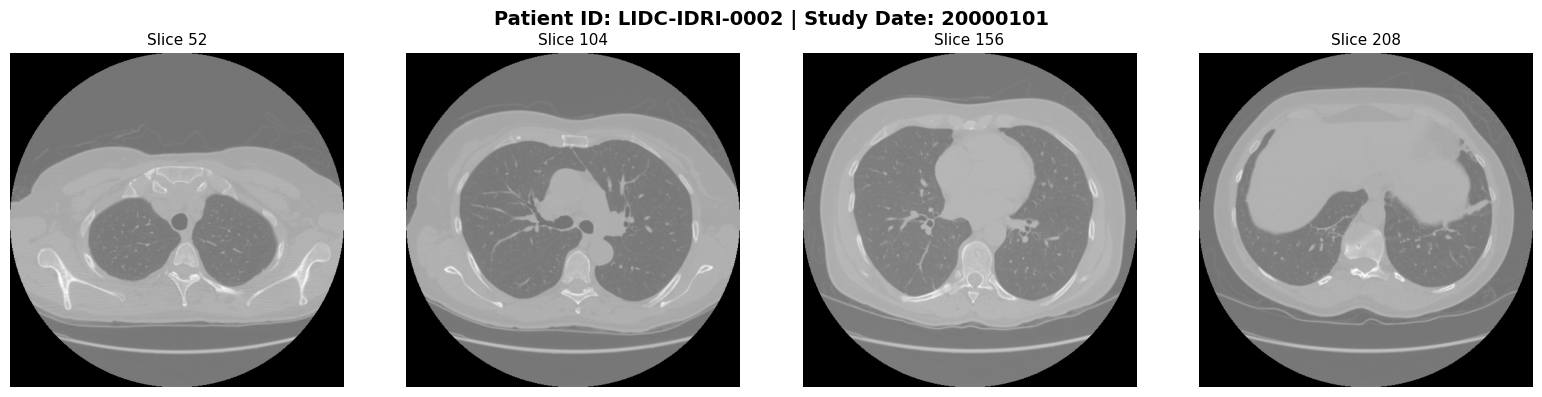

In [50]:
import matplotlib.pyplot as plt
from pathlib import Path
import pydicom
import pandas as pd

def visualize_ct_series(manifest_row: pd.Series):
    # 1. Validation
    modality = str(manifest_row.get('modality', '')).upper()
    n_images = int(manifest_row.get('n_images', 0))
    if modality != 'CT' or n_images <= 1:
        raise ValueError("Must be a CT series with n_images > 1.")

    # 2. Load DICOM files
    series_path = Path(manifest_row['series_path'])
    loaded_slices = [pydicom.dcmread(f) for f in series_path.glob("*.dcm")]

    # 3. Sort by InstanceNumber
    loaded_slices.sort(key=lambda s: int(s.get('InstanceNumber', 0)))

    # 4. Pick indices (0-based) for 20%, 40%, 60%, 80%
    total_slices = len(loaded_slices)
    sample_indices = [int(p * total_slices) for p in [0.2, 0.4, 0.6, 0.8]]

    # 5. Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    patient_id = manifest_row.get('patient_id', 'Unknown')
    study_date = manifest_row.get('study_date', 'Unknown')
    fig.suptitle(f"Patient ID: {patient_id} | Study Date: {study_date}", fontsize=14, fontweight='bold')

    for ax, idx in zip(axes, sample_indices):
        slice_ds = loaded_slices[idx]
        ax.imshow(slice_ds.pixel_array, cmap='gray')
        ax.set_title(f"Slice {idx}", fontsize=11)  # Sets 52, 104, 156, 208
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

# --- Run Function on Patient 0002 ---
ct_row = manifest_df[(manifest_df['patient_id'] == 'LIDC-IDRI-0002') & (manifest_df['modality'] == 'CT')].iloc[0]
visualize_ct_series(ct_row)

In [51]:
#Challenge Case: Show the result for patient LIDC-IDRI-0001

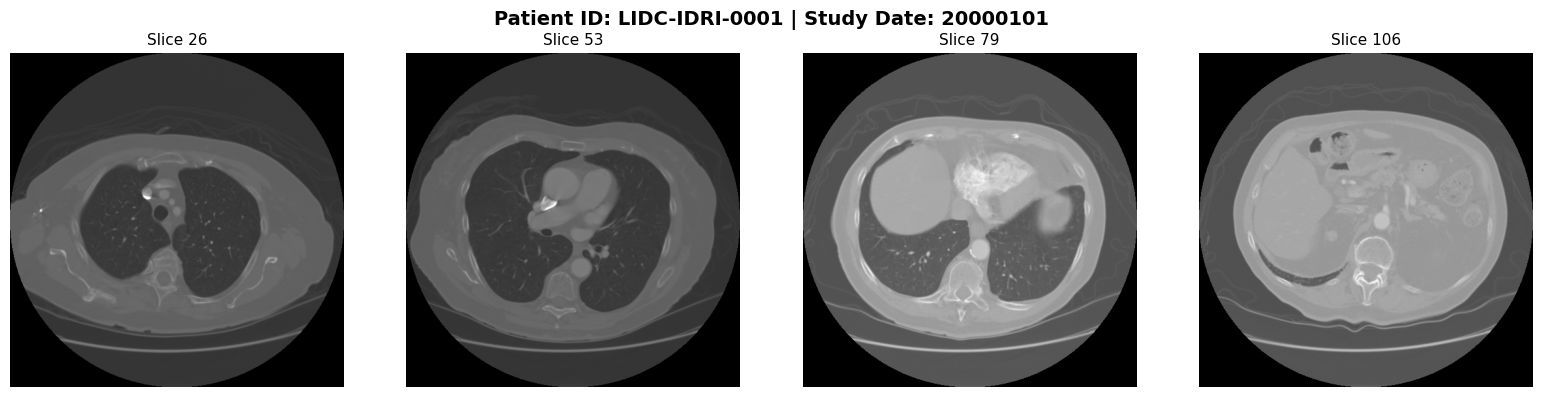

In [52]:
ct_row = manifest_df[(manifest_df['patient_id'] == 'LIDC-IDRI-0001') & (manifest_df['modality'] == 'CT')].iloc[0]
visualize_ct_series(ct_row)